# PrivacyAlert Caption Generation Notebook

This notebook is the PrivacyAlert version of the DIPA2 caption-generation notebook.

Main behavior:
- Uses your unzipped `PrivacyAlert` folder in Google Drive.
- Expects images inside `PrivacyAlert/test/images`.
- Reads PrivacyAlert labels/tags from `PrivacyAlert/privacy_detection_dataset_v2`.
- Loads image keywords from `ImgTags/ut`, `ImgTags/dt`, and optionally `ImgTags/utdt`.
- Aggregates multiple keyword/tag sources per image before generation.
- Uses **keywords**, not taxonomy categories, to induce privacy-revealing captions.
- Processes each image once using aggregated PrivacyAlert keyword context.

Default Drive layout expected by this notebook:

```text
/content/drive/MyDrive/PrivacyAlert/
  test/
    images/
    metadata/
  privacy_detection_dataset_v2/
    Dataset_split/
    ImgTags/
    ImFiles/
```


## 1. Mount Drive

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Install dependencies

In [ ]:

!pip -q install -U google-genai pandas pillow matplotlib tqdm requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


## 3. Paths, model, and run settings

This version is adjusted for your current Drive folder layout where images are inside the **test folder**:

```text
/content/drive/MyDrive/PrivacyAlert/test/images
```

The original PrivacyAlert metadata/tag files are expected here:

```text
/content/drive/MyDrive/PrivacyAlert/privacy_detection_dataset_v2
```

Change only `PRIVACYALERT_BASE` if your unzipped `PrivacyAlert` folder is somewhere else.


In [ ]:

from pathlib import Path
import os

# ---------------------------------------------------------------------
# PrivacyAlert dataset paths
# ---------------------------------------------------------------------
# Expected Drive layout:
# /content/drive/MyDrive/PrivacyAlert/
#   test/images
#   test/metadata
#   privacy_detection_dataset_v2/Dataset_split
#   privacy_detection_dataset_v2/ImgTags
#   privacy_detection_dataset_v2/ImFiles

CANDIDATE_PRIVACYALERT_BASES = [
    Path('/content/drive/MyDrive/PrivacyAlert'),
    Path('/content/drive/MyDrive/privacyalert'),
]

PRIVACYALERT_BASE = next(
    (
        p for p in CANDIDATE_PRIVACYALERT_BASES
        if (p / 'test' / 'images').exists()
        and (p / 'privacy_detection_dataset_v2' / 'Dataset_split').exists()
        and (p / 'privacy_detection_dataset_v2' / 'ImgTags').exists()
    ),
    CANDIDATE_PRIVACYALERT_BASES[0],
)

# This is the original PrivacyAlert metadata/tag folder.
PRIVACYALERT_ROOT = PRIVACYALERT_BASE / 'privacy_detection_dataset_v2'

# This is your actual downloaded image folder.
TEST_IMAGE_DIR = PRIVACYALERT_BASE / 'test' / 'images'
TEST_METADATA_DIR = PRIVACYALERT_BASE / 'test' / 'metadata'

SPLIT_DIR = PRIVACYALERT_ROOT / 'Dataset_split'
IMFILES_DIR = PRIVACYALERT_ROOT / 'ImFiles'
IMGTAGS_DIR = PRIVACYALERT_ROOT / 'ImgTags'

# Search images from the folder you said contains the test images.
# Extra fallbacks are included only to make the notebook robust if you move files later.
IMAGE_SEARCH_ROOTS = [
    TEST_IMAGE_DIR,
    PRIVACYALERT_BASE / 'test',
    PRIVACYALERT_ROOT / 'images',
    PRIVACYALERT_ROOT,
]

# Optional downloader target. Usually not needed because your images are already in test/images.
DOWNLOAD_IMAGE_DIR = TEST_IMAGE_DIR

# ---------------------------------------------------------------------
# Output paths
# ---------------------------------------------------------------------
RUN_ROOT = PRIVACYALERT_BASE / 'experiments' / 'caption_generation_keyword_induced_final_v2'
OUTPUT_DIR = RUN_ROOT / 'captions_v1'
FAILED_JSON_DIR = RUN_ROOT / 'failed_jsons_v1'
REPORT_DIR = RUN_ROOT / 'reports'
GRAPH_DIR = RUN_ROOT / 'graphs'

STATUS_CSV_PATH = RUN_ROOT / 'image_status_log.csv'
CONTEXT_CSV_PATH = RUN_ROOT / 'privacyalert_image_level_context.csv'

for p in [RUN_ROOT, OUTPUT_DIR, FAILED_JSON_DIR, REPORT_DIR, GRAPH_DIR, DOWNLOAD_IMAGE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('PRIVACYALERT_BASE:', PRIVACYALERT_BASE)
print('PRIVACYALERT_ROOT:', PRIVACYALERT_ROOT)
print('TEST_IMAGE_DIR:', TEST_IMAGE_DIR)
print('TEST_METADATA_DIR:', TEST_METADATA_DIR)
print('SPLIT_DIR:', SPLIT_DIR)
print('IMFILES_DIR:', IMFILES_DIR)
print('IMGTAGS_DIR:', IMGTAGS_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

assert PRIVACYALERT_BASE.exists(), f'Missing PrivacyAlert base folder: {PRIVACYALERT_BASE}'
assert TEST_IMAGE_DIR.exists(), f'Missing test image folder: {TEST_IMAGE_DIR}'
assert SPLIT_DIR.exists(), f'Missing split folder: {SPLIT_DIR}'
assert IMGTAGS_DIR.exists(), f'Missing ImgTags folder: {IMGTAGS_DIR}'

# ---------------------------------------------------------------------
# Gemini/API settings
# ---------------------------------------------------------------------
MODEL_STAGE1 = 'gemini-3.1-flash-lite'  # change if needed
TEMPERATURE_STAGE1 = 0.9

# Test first with a small number, then set None for full run.
MAX_IMAGES = None
SKIP_IF_JSON_EXISTS = True
SKIP_FAILED_IF_LOGGED = False

# Async settings. Increase carefully if you have quota.
TOTAL_CONCURRENCY = 4
REQUESTS_PER_KEY = 500

# ---------------------------------------------------------------------
# PrivacyAlert processing settings
# ---------------------------------------------------------------------
# Images are inside test/images, so default to the test split.
# Options: 'train', 'val', 'test', 'all'
SPLIT_TO_PROCESS = 'test'

# Options:
# - False: process public and private images
# - True: process only images labeled Private
PROCESS_ONLY_PRIVATE = False

# Keyword source handling:
# - user_tags come from ImgTags/ut
# - deep_tags come from ImgTags/dt
# - utdt is usually redundant because it is the concatenation of user tags and deep tags
USE_USER_TAGS = True
USE_DEEP_TAGS = True
USE_UTDT_TAGS = False

# Keyword filtering for prompt length and quality.
MAX_KEYWORDS_PER_SOURCE = 60
MAX_AGGREGATED_KEYWORDS = 80
MIN_KEYWORD_LEN = 2

# Only process images that have at least one keyword after aggregation.
PROCESS_ONLY_IMAGES_WITH_KEYWORDS = True


PRIVACYALERT_BASE: /content/drive/MyDrive/PrivacyAlert
PRIVACYALERT_ROOT: /content/drive/MyDrive/PrivacyAlert/privacy_detection_dataset_v2
TEST_IMAGE_DIR: /content/drive/MyDrive/PrivacyAlert/test/images
TEST_METADATA_DIR: /content/drive/MyDrive/PrivacyAlert/test/metadata
SPLIT_DIR: /content/drive/MyDrive/PrivacyAlert/privacy_detection_dataset_v2/Dataset_split
IMFILES_DIR: /content/drive/MyDrive/PrivacyAlert/privacy_detection_dataset_v2/ImFiles
IMGTAGS_DIR: /content/drive/MyDrive/PrivacyAlert/privacy_detection_dataset_v2/ImgTags
OUTPUT_DIR: /content/drive/MyDrive/PrivacyAlert/experiments/caption_generation_keyword_induced_final_v2/captions_v1


## 4. API keys

Recommended: store your key in Colab Secrets as `GOOGLE_API_KEY`.

Do **not** hard-code real API keys in a shared notebook.

In [ ]:

import os

MANUAL_API_KEYS = [
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
]

def get_colab_secret(name: str):
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return None

API_KEYS = [k for k in MANUAL_API_KEYS if k and 'paste_' not in k]

if not API_KEYS:
    secret_key = get_colab_secret('GOOGLE_API_KEY')
    if secret_key:
        API_KEYS = [secret_key]

if not API_KEYS and os.environ.get('GOOGLE_API_KEY'):
    API_KEYS = [os.environ['GOOGLE_API_KEY']]

print('Number of API keys loaded:', len(API_KEYS))
if not API_KEYS:
    raise ValueError('No API key found. Add GOOGLE_API_KEY in Colab Secrets or paste keys into MANUAL_API_KEYS.')

Number of API keys loaded: 10


## 5. Load PrivacyAlert labels, URLs, and keywords

PrivacyAlert does not provide DIPA2-style object categories in this zip. Instead, it provides image-level public/private labels and keyword tags.

We aggregate keywords from multiple sources:
- `ut`: user tags
- `dt`: deep tags
- `utdt`: combined user + deep tags, usually redundant

The generated caption should use these **keywords as semantic anchors**, not as taxonomy labels.

In [ ]:

import csv
import json
import re
from pathlib import Path
from collections import Counter, defaultdict
from typing import Any, Dict, List, Set, Tuple

import pandas as pd
import numpy as np

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

SPLIT_FILE_MAP = {
    'train': 'train_with_labels_2classes.csv',
    'val': 'val_with_labels_2classes.csv',
    'test': 'test_with_labels_2classes.csv',
}

URL_FILE_MAP = {
    'train': 'train_urls.csv',
    'val': 'val_urls.csv',
    'test': 'test_urls.csv',
}

TAG_SOURCE_DIRS = {
    'user_tags': 'ut',
    'deep_tags': 'dt',
    'combined_utdt': 'utdt',
}

TAG_FILE_SPLIT_MAP = {
    'train': 'dt_plus_ut_train1_2.tsv',
    'val': 'dt_plus_ut_val1_2.tsv',
    'test': 'dt_plus_ut_test1_2.tsv',
    'all': 'dt_plus_ut_overall1_2.tsv',
}

def normalize_image_id(x) -> str:
    s = str(x).strip()
    s = re.sub(r'\.0$', '', s)
    return s

def normalize_privacy_label(x) -> str:
    s = str(x).strip().lower()
    if s in {'private', '1', 'true'}:
        return 'Private'
    if s in {'public', '0', 'false'}:
        return 'Public'
    return str(x).strip()

def load_split_labels(split_dir: Path) -> pd.DataFrame:
    rows = []
    for split, fname in SPLIT_FILE_MAP.items():
        path = split_dir / fname
        if not path.exists():
            print('Missing split file:', path)
            continue
        df = pd.read_csv(path)
        df['image_id'] = df['Filename'].map(normalize_image_id)
        df['privacy'] = df['privacy'].map(normalize_privacy_label)
        df['binary_privacy'] = df['privacy'].map({'Public': 0, 'Private': 1})
        df['split'] = split
        rows.append(df[['image_id', 'privacy', 'binary_privacy', 'split']])
    return pd.concat(rows, ignore_index=True).drop_duplicates(subset=['image_id', 'split'])

def load_urls(imfiles_dir: Path) -> pd.DataFrame:
    rows = []
    for split, fname in URL_FILE_MAP.items():
        path = imfiles_dir / fname
        if not path.exists():
            print('Missing URL file:', path)
            continue
        df = pd.read_csv(path)
        df['split'] = split
        df['url_order'] = range(len(df))
        rows.append(df[['split', 'url_order', 'urls']])
    if not rows:
        return pd.DataFrame(columns=['split', 'url_order', 'urls'])
    return pd.concat(rows, ignore_index=True)

def load_tag_file(path: Path, source_name: str, split_hint: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['idx', 'binary_privacy_from_tags', 'image_id', 'raw_keywords', 'tag_source', 'tag_split'])
    df = pd.read_csv(
        path,
        sep='\t',
        header=None,
        names=['idx', 'binary_privacy_from_tags', 'image_id', 'raw_keywords'],
        dtype={'image_id': str},
        quoting=csv.QUOTE_NONE,
        on_bad_lines='skip',
    )
    df['image_id'] = df['image_id'].map(normalize_image_id)
    df['raw_keywords'] = df['raw_keywords'].fillna('').astype(str)
    df['tag_source'] = source_name
    df['tag_split'] = split_hint
    return df

def load_all_tag_sources(imgtags_dir: Path) -> pd.DataFrame:
    enabled_sources = []
    if USE_USER_TAGS:
        enabled_sources.append('user_tags')
    if USE_DEEP_TAGS:
        enabled_sources.append('deep_tags')
    if USE_UTDT_TAGS:
        enabled_sources.append('combined_utdt')

    rows = []
    for source_name in enabled_sources:
        subdir = imgtags_dir / TAG_SOURCE_DIRS[source_name]
        for split_hint, fname in TAG_FILE_SPLIT_MAP.items():
            # Load split-specific files. Overall is useful for global context but can duplicate split rows.
            # We skip 'all' by default when split files exist because split-specific rows are cleaner.
            if split_hint == 'all':
                continue
            path = subdir / fname
            df = load_tag_file(path, source_name, split_hint)
            if len(df):
                rows.append(df)
    if not rows:
        return pd.DataFrame(columns=['idx', 'binary_privacy_from_tags', 'image_id', 'raw_keywords', 'tag_source', 'tag_split'])
    return pd.concat(rows, ignore_index=True)

def basic_keyword_tokens(text: str) -> list[str]:
    """
    PrivacyAlert keyword strings are mostly whitespace-separated tags.
    This keeps simple tokens, de-duplicates them later, and avoids using categories.
    """
    text = str(text or '')
    text = text.replace('&', ' ')
    parts = re.split(r'[\s,;|/]+', text)
    out = []
    for p in parts:
        p = p.strip().lower()
        p = re.sub(r'^[^a-z0-9]+|[^a-z0-9]+$', '', p)
        if len(p) < MIN_KEYWORD_LEN:
            continue
        if p in {'and', 'or', 'the', 'a', 'an', 'of', 'to', 'in', 'on', 'for', 'with', 'by'}:
            continue
        out.append(p)
    return out

def select_keywords_for_prompt(counter: Counter, max_keywords: int) -> list[tuple[str, int]]:
    # Sort by support/count first, then alphabetically for stable outputs.
    return sorted(counter.items(), key=lambda kv: (-kv[1], kv[0]))[:max_keywords]

split_labels_df = load_split_labels(SPLIT_DIR)
urls_df = load_urls(IMFILES_DIR)
tag_rows_df = load_all_tag_sources(IMGTAGS_DIR)

print('Split label rows:', len(split_labels_df), 'unique images:', split_labels_df['image_id'].nunique())
print('URL rows:', len(urls_df))
print('Tag rows:', len(tag_rows_df), 'unique images:', tag_rows_df['image_id'].nunique())

display(split_labels_df.head())
display(tag_rows_df.head())

Split label rows: 6800 unique images: 6800
URL rows: 6800
Tag rows: 13600 unique images: 6800


,image_id,privacy,binary_privacy,split
0,51027421626,Public,0,train
1,50668571902,Public,0,train
2,51196330717,Public,0,train
3,51192228348,Public,0,train
4,51040407237,Public,0,train


,idx,binary_privacy_from_tags,image_id,raw_keywords,tag_source,tag_split
0,0,0,51027421626,Denver COVID-19 death children VIVID&STRIKING ...,user_tags,train
1,1,0,50668571902,bouddhisme tibetain children moine tibetain pe...,user_tags,train
2,2,0,51196330717,أطفال Children,user_tags,train
3,3,0,51192228348,139th AW 139th Airlift Wing Community Engageme...,user_tags,train
4,4,0,51040407237,agriculture boy child children fruit kid produ...,user_tags,train


## 6. Aggregate multiple keyword annotations per image

This is the PrivacyAlert equivalent of DIPA2 multi-annotator aggregation.

For each image, it builds one context containing:
- public/private label
- split name
- user-tag keywords
- deep-tag keywords
- keyword support across sources
- raw keyword strings from the original files

The model will use these keywords to choose a privacy-revealing caption angle.

In [ ]:

def aggregate_privacyalert_by_image(
    split_labels: pd.DataFrame,
    tag_rows: pd.DataFrame,
    urls: pd.DataFrame | None = None,
) -> dict:
    contexts = {}

    # Create labels lookup. If same image appears once per split, keep split-specific rows.
    if SPLIT_TO_PROCESS == 'all':
        label_rows = split_labels.copy()
    else:
        label_rows = split_labels[split_labels['split'] == SPLIT_TO_PROCESS].copy()

    # Merge URL by order when possible: split label files and URL files are in same order.
    url_lookup = {}
    if urls is not None and len(urls):
        for split in ['train', 'val', 'test']:
            labels_split = split_labels[split_labels['split'] == split].reset_index(drop=True)
            urls_split = urls[urls['split'] == split].reset_index(drop=True)
            n = min(len(labels_split), len(urls_split))
            for i in range(n):
                url_lookup[(split, labels_split.loc[i, 'image_id'])] = urls_split.loc[i, 'urls']

    grouped_tags = tag_rows.groupby('image_id') if len(tag_rows) else {}

    for _, row in label_rows.iterrows():
        image_id = normalize_image_id(row['image_id'])
        split = row['split']
        privacy = row['privacy']
        binary_privacy = int(row['binary_privacy']) if pd.notna(row['binary_privacy']) else None

        if PROCESS_ONLY_PRIVATE and privacy != 'Private':
            continue

        if len(tag_rows) and image_id in grouped_tags.groups:
            tg = grouped_tags.get_group(image_id)
        else:
            tg = pd.DataFrame(columns=tag_rows.columns)

        source_summaries = []
        source_keyword_counters = {}
        aggregate_counter = Counter()
        keyword_source_counter = defaultdict(set)

        for source_name, sg in tg.groupby('tag_source') if len(tg) else []:
            raw_strings = sg['raw_keywords'].dropna().astype(str).tolist()
            counter = Counter()
            for raw in raw_strings:
                toks = basic_keyword_tokens(raw)
                counter.update(toks)
            top_keywords = select_keywords_for_prompt(counter, MAX_KEYWORDS_PER_SOURCE)
            source_keyword_counters[source_name] = counter
            aggregate_counter.update(counter)
            for kw in counter:
                keyword_source_counter[kw].add(source_name)
            source_summaries.append({
                'source': source_name,
                'num_rows': int(len(sg)),
                'binary_labels_in_tag_file': sorted(set([int(x) for x in sg['binary_privacy_from_tags'].dropna().tolist()])),
                'top_keywords': top_keywords,
                'raw_keyword_examples': raw_strings[:3],
            })

        keyword_support = []
        for kw, count in aggregate_counter.items():
            keyword_support.append({
                'keyword': kw,
                'count': int(count),
                'sources': sorted(keyword_source_counter.get(kw, [])),
                'source_count': len(keyword_source_counter.get(kw, [])),
            })
        keyword_support = sorted(keyword_support, key=lambda x: (-x['source_count'], -x['count'], x['keyword']))[:MAX_AGGREGATED_KEYWORDS]

        contexts[image_id] = {
            'image_id': image_id,
            'split': split,
            'privacy': privacy,
            'binary_privacy': binary_privacy,
            'url': url_lookup.get((split, image_id)),
            'num_tag_rows': int(len(tg)),
            'tag_sources_present': sorted(tg['tag_source'].dropna().astype(str).unique().tolist()) if len(tg) else [],
            'source_summaries': source_summaries,
            'aggregated_keywords': keyword_support,
        }

    return contexts

def context_to_prompt_text(context: dict | None) -> str:
    if not context:
        return (
            "No PrivacyAlert keyword context was found for this image. "
            "Use the image only and create caption-induced privacy context only when it fits the image."
        )

    keywords = [x["keyword"] for x in context.get("aggregated_keywords", [])]
    grounded_keywords = [
        x["keyword"] for x in context.get("aggregated_keywords", [])
        if x.get("source_count", 0) >= 1
    ]

    lines = []
    lines.append(f"image_id: {context['image_id']}")
    lines.append(f"split: {context.get('split')}")
    lines.append(f"privacy_label: {context.get('privacy')}")
    lines.append(f"binary_privacy: {context.get('binary_privacy')}")
    lines.append(f"cleaned_image_keywords: {keywords[:80]}")
    lines.append(f"image_grounded_privacy_keywords: {grounded_keywords[:80]}")
    lines.append(f"num_keyword_annotation_rows: {context.get('num_tag_rows')}")
    lines.append(f"tag_sources_present: {context.get('tag_sources_present', [])}")
    lines.append("")
    lines.append("Aggregated PrivacyAlert keyword evidence:")
    for item in context.get("aggregated_keywords", [])[:MAX_AGGREGATED_KEYWORDS]:
        lines.append(
            f"- keyword='{item['keyword']}': count={item['count']}, "
            f"sources={item['sources']}, source_count={item['source_count']}"
        )
    lines.append("")
    lines.append("Keyword source summaries:")
    for src in context.get("source_summaries", []):
        lines.append(f"- {src['source']}: rows={src['num_rows']}, binary_labels={src['binary_labels_in_tag_file']}")
        lines.append(f"  top_keywords={src['top_keywords'][:30]}")
        if src.get("raw_keyword_examples"):
            lines.append(f"  raw_keyword_examples={src['raw_keyword_examples'][:2]}")
    return "\n".join(lines)

privacyalert_contexts = aggregate_privacyalert_by_image(split_labels_df, tag_rows_df, urls_df)

print('Image contexts built:', len(privacyalert_contexts))
print('Privacy labels in contexts:')
print(pd.Series([c['privacy'] for c in privacyalert_contexts.values()]).value_counts())

context_rows = []
for image_id, ctx in privacyalert_contexts.items():
    context_rows.append({
        'image_id': image_id,
        'split': ctx.get('split'),
        'privacy': ctx.get('privacy'),
        'binary_privacy': ctx.get('binary_privacy'),
        'url': ctx.get('url'),
        'num_tag_rows': ctx.get('num_tag_rows'),
        'tag_sources_present': json.dumps(ctx.get('tag_sources_present', []), ensure_ascii=False),
        'aggregated_keywords': json.dumps(ctx.get('aggregated_keywords', []), ensure_ascii=False),
        'source_summaries': json.dumps(ctx.get('source_summaries', []), ensure_ascii=False),
    })
context_df = pd.DataFrame(context_rows)
context_df.to_csv(CONTEXT_CSV_PATH, index=False)
print('Saved context CSV:', CONTEXT_CSV_PATH)

display(context_df.head())

Image contexts built: 1800
Privacy labels in contexts:
Public     1350
Private     450
Name: count, dtype: int64
Saved context CSV: /content/drive/MyDrive/PrivacyAlert/experiments/caption_generation_keyword_induced_final_v2/privacyalert_image_level_context.csv


,image_id,split,privacy,binary_privacy,url,num_tag_rows,tag_sources_present,aggregated_keywords,source_summaries
0,49910698552,test,Public,0,https://live.staticflickr.com/65535/4991069855...,2,"[""deep_tags"", ""user_tags""]","[{""keyword"": ""sense"", ""count"": 2, ""sources"": [...","[{""source"": ""deep_tags"", ""num_rows"": 1, ""binar..."
1,50783798341,test,Public,0,https://live.staticflickr.com/65535/5078379834...,2,"[""deep_tags"", ""user_tags""]","[{""keyword"": ""nunn"", ""count"": 3, ""sources"": [""...","[{""source"": ""deep_tags"", ""num_rows"": 1, ""binar..."
2,51223478856,test,Public,0,https://live.staticflickr.com/65535/5122347885...,2,"[""deep_tags"", ""user_tags""]","[{""keyword"": ""bench"", ""count"": 2, ""sources"": [...","[{""source"": ""deep_tags"", ""num_rows"": 1, ""binar..."
3,51161663162,test,Private,1,https://live.staticflickr.com/65535/5116166316...,2,"[""deep_tags"", ""user_tags""]","[{""keyword"": ""jean"", ""count"": 2, ""sources"": [""...","[{""source"": ""deep_tags"", ""num_rows"": 1, ""binar..."
4,50733625473,test,Public,0,https://live.staticflickr.com/65535/5073362547...,2,"[""deep_tags"", ""user_tags""]","[{""keyword"": ""neck"", ""count"": 2, ""sources"": [""...","[{""source"": ""deep_tags"", ""num_rows"": 1, ""binar..."


## 7. Find test image files and check coverage

This maps image IDs like `51027421626` to files in Drive.

This notebook now searches the actual folder:

```text
/content/drive/MyDrive/PrivacyAlert/test/images
```

Supported filename patterns include:
- `51027421626.jpg`
- `51027421626.png`
- `51027421626_some_flickr_suffix.jpg`


In [ ]:

def image_id_from_path(path: Path) -> str:
    stem = path.stem
    # Flickr filenames commonly start with the photo ID followed by underscore.
    first = stem.split('_')[0]
    if first.isdigit():
        return first
    return stem

def find_image_files(search_roots: list[Path]) -> dict:
    id_to_path = {}
    all_paths = []
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for p in root.rglob('*'):
            if not p.is_file() or p.suffix.lower() not in IMAGE_EXTS:
                continue
            # Avoid macOS metadata and output folders.
            if '__MACOSX' in str(p):
                continue
            if str(RUN_ROOT) in str(p):
                continue
            if p in seen:
                continue
            seen.add(p)
            all_paths.append(p)
            image_id = image_id_from_path(p)
            id_to_path.setdefault(image_id, p)
    return id_to_path, sorted(all_paths)

image_id_to_path, all_image_files = find_image_files(IMAGE_SEARCH_ROOTS)
context_image_ids = set(privacyalert_contexts.keys())
images_with_keywords = {
    image_id for image_id, ctx in privacyalert_contexts.items()
    if len(ctx.get('aggregated_keywords', [])) > 0
}
images_with_files = set(image_id_to_path.keys())

missing_files = sorted(context_image_ids - images_with_files)
files_without_context = sorted(images_with_files - context_image_ids)
no_keyword_context = sorted(context_image_ids - images_with_keywords)

print('Image files found:', len(all_image_files))
print('Image IDs with files:', len(images_with_files))
print('PrivacyAlert contexts:', len(context_image_ids))
print('Images with keywords:', len(images_with_keywords))
print('Contexts missing image file:', len(missing_files))
print('Image files without context:', len(files_without_context))
print('Contexts with no usable keywords:', len(no_keyword_context))

if missing_files[:10]:
    print('Examples missing image file:', missing_files[:10])
if files_without_context[:10]:
    print('Examples files without context:', files_without_context[:10])
if no_keyword_context[:10]:
    print('Examples no keyword context:', no_keyword_context[:10])

eligible_ids = context_image_ids & images_with_files
if PROCESS_ONLY_IMAGES_WITH_KEYWORDS:
    eligible_ids = eligible_ids & images_with_keywords

images_to_process = [image_id_to_path[i] for i in sorted(eligible_ids)]

if MAX_IMAGES is not None:
    images_to_process = images_to_process[:MAX_IMAGES]

print('\nFINAL MODEL INPUT')
print('Images to process:', len(images_to_process))
print('Images dropped before model because file missing:', len(context_image_ids - images_with_files))
print('Images dropped before model because no keywords:', len(no_keyword_context) if PROCESS_ONLY_IMAGES_WITH_KEYWORDS else 0)
print('First 5 image paths:', images_to_process[:5])

# Save audit lists.
pd.DataFrame({'image_id': missing_files, 'drop_reason': 'missing_image_file'}).to_csv(REPORT_DIR / 'missing_image_files.csv', index=False)
pd.DataFrame({'image_id': no_keyword_context, 'drop_reason': 'no_usable_keywords'}).to_csv(REPORT_DIR / 'no_keyword_context.csv', index=False)
print('Saved audit CSVs to:', REPORT_DIR)

Image files found: 1554
Image IDs with files: 1554
PrivacyAlert contexts: 1800
Images with keywords: 1800
Contexts missing image file: 246
Image files without context: 0
Contexts with no usable keywords: 0
Examples missing image file: ['10802197565', '11627173554', '12572360524', '13358227345', '13439176005', '14121230978', '16038848241', '16128414077', '16675779678', '16845108719']

FINAL MODEL INPUT
Images to process: 1554
Images dropped before model because file missing: 246
Images dropped before model because no keywords: 0
First 5 image paths: [PosixPath('/content/drive/MyDrive/PrivacyAlert/test/images/10560439084.jpg'), PosixPath('/content/drive/MyDrive/PrivacyAlert/test/images/10707237203.jpg'), PosixPath('/content/drive/MyDrive/PrivacyAlert/test/images/10742233915.jpg'), PosixPath('/content/drive/MyDrive/PrivacyAlert/test/images/10752868816.jpg'), PosixPath('/content/drive/MyDrive/PrivacyAlert/test/images/10798167965.jpg')]
Saved audit CSVs to: /content/drive/MyDrive/PrivacyAle

## 8. Optional: download missing images from PrivacyAlert URLs

You probably do **not** need this because your images are already inside:

```text
/content/drive/MyDrive/PrivacyAlert/test/images
```

Use this only if some expected test images are missing. The cell downloads images into `TEST_IMAGE_DIR` as `{image_id}.jpg`.

Start with a small number by setting `MAX_DOWNLOADS = 20`.


In [ ]:

# OPTIONAL CELL. Set RUN_DOWNLOADER = True if needed.
RUN_DOWNLOADER = False
MAX_DOWNLOADS = 20  # set None for all missing images in the selected split
DOWNLOAD_TIMEOUT = 20

if RUN_DOWNLOADER:
    import requests
    from tqdm.auto import tqdm

    DOWNLOAD_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

    missing_to_download = [i for i in sorted(context_image_ids) if i not in image_id_to_path and privacyalert_contexts[i].get('url')]
    if MAX_DOWNLOADS is not None:
        missing_to_download = missing_to_download[:MAX_DOWNLOADS]

    print('Downloading images:', len(missing_to_download))
    downloaded = 0
    failed = []
    for image_id in tqdm(missing_to_download):
        url = privacyalert_contexts[image_id].get('url')
        out_path = DOWNLOAD_IMAGE_DIR / f'{image_id}.jpg'
        if out_path.exists():
            downloaded += 1
            continue
        try:
            r = requests.get(url, timeout=DOWNLOAD_TIMEOUT, headers={'User-Agent': 'Mozilla/5.0'})
            r.raise_for_status()
            if not r.content:
                raise ValueError('empty response')
            out_path.write_bytes(r.content)
            downloaded += 1
        except Exception as e:
            failed.append({'image_id': image_id, 'url': url, 'error': repr(e)})

    print('Downloaded/existing:', downloaded)
    print('Failed:', len(failed))
    if failed:
        pd.DataFrame(failed).to_csv(REPORT_DIR / 'download_failed.csv', index=False)
        display(pd.DataFrame(failed).head())

    # Re-run Cell 7 after downloading.

## 9. Preview one aggregated keyword context

In [ ]:

import random

if images_to_process:
    sample_image = random.choice(images_to_process)
    sample_image_id = image_id_from_path(sample_image)
    print('Sample image:', sample_image)
    print('Sample image_id:', sample_image_id)
    print()
    print(context_to_prompt_text(privacyalert_contexts.get(sample_image_id))[:6000])
else:
    print('No images_to_process. Check image paths or run optional downloader.')

Sample image: /content/drive/MyDrive/PrivacyAlert/test/images/22477025123.jpg
Sample image_id: 22477025123

image_id: 22477025123
split: test
privacy_label: Public
binary_privacy: 0
cleaned_image_keywords: ['movie', 'church', 'eating', 'house', 'altar', 'barber', 'barbershop', 'building', 'car', 'carriage', 'chair', 'cinema', 'coach', 'dining', 'eatery', 'furnishings', 'hotels', 'inns', 'interiors', 'library', 'monastery', 'palace', 'passenger', 'picture', 'place', 'restaurant', 'rooms', 'tables', 'taverns', 'theater', 'theatre', 'vault']
image_grounded_privacy_keywords: ['movie', 'church', 'eating', 'house', 'altar', 'barber', 'barbershop', 'building', 'car', 'carriage', 'chair', 'cinema', 'coach', 'dining', 'eatery', 'furnishings', 'hotels', 'inns', 'interiors', 'library', 'monastery', 'palace', 'passenger', 'picture', 'place', 'restaurant', 'rooms', 'tables', 'taverns', 'theater', 'theatre', 'vault']
num_keyword_annotation_rows: 2
tag_sources_present: ['deep_tags', 'user_tags']

Agg

## 10. PrivacyAlert keyword-based prompt

This prompt does **not** use taxonomy categories. It uses PrivacyAlert keywords as the caption anchors.

In [ ]:
PRIVACYALERT_KEYWORD_GUIDE = {
    # =====================================================
    # PRIVACYALERT ORIGINAL KEYWORD TAXONOMY
    # =====================================================
    # This is NOT an output-label set.
    # These groups help the model interpret PrivacyAlert keywords and choose
    # privacy-revealing caption angles. Output should use keyword_anchors.

    "nudity_sexual": {
        "description": (
            "People with full nudity, semi-nudity, sexualized pose, intimate exposure, kissing, or body exposure. "
            "Use only when the image/keywords strongly support it. Keep captions tasteful, non-explicit, and non-graphic."
        ),
        "keywords": [
            "bare", "body", "breasts", "butt", "erotic", "naked", "nudity",
            "sexual", "shirtless", "kissing"
        ],
        "caption_angles": [
            "beachwear or changing context",
            "private body/self-presentation",
            "intimate or sensitive personal moment",
            "appearance-related exposure"
        ],
    },

    "other_people": {
        "description": (
            "Photos of or with people the owner knows, the owner themselves, bystanders, spectators, family members, "
            "children, partners, or social events. Use when people/social context can reveal identity, relationship, "
            "family, group membership, or bystander privacy."
        ),
        "keywords": [
            "grandparent", "children", "spectator", "boy", "family", "husband",
            "kids", "parents", "partner", "people", "wife", "family"
        ],
        "caption_angles": [
            "family or relationship context",
            "group/social-circle context",
            "bystander or spectator privacy",
            "children/family event",
            "private gathering or social plan"
        ],
    },

    "unorganized_home": {
        "description": (
            "Messy, unorganized, private, or revealing home interiors. Use when the caption can reveal living situation, "
            "home routine, private room context, household state, or personal domestic life."
        ),
        "keywords": [
            "messy room", "toilet", "uncleaned pool", "bathroom", "disorganized",
            "restroom", "unclean", "indoor", "bedroom", "kitchen", "living room",
            "desk", "sofa", "trash", "closet"
        ],
        "caption_angles": [
            "home/living situation",
            "private room or household routine",
            "messy personal space",
            "domestic habit or private life"
        ],
    },

    "violence": {
        "description": (
            "Violent scenes, weapons, war, military context, shooting, damage, battlefield, terrorism, or dangerous content. "
            "Use neutral, non-graphic wording."
        ),
        "keywords": [
            "damage", "guns", "violence", "war", "military", "shooting",
            "firearms", "weapons", "corps", "battlefield", "tourisms",
            "theater", "legal", "license"
        ],
        "caption_angles": [
            "unsafe event context",
            "legal/security situation",
            "weapon or military context",
            "damage or incident aftermath"
        ],
    },

    "medical": {
        "description": (
            "Photos of medical condition, visible blood, injury, skin condition, surgery, pharmacy, emergency, pain, "
            "medical treatment, or health-related details. Keep captions human, respectful, and non-graphic."
        ),
        "keywords": [
            "eye", "abscess", "peeling skin", "bad teeth", "acne", "bloody",
            "injury", "wound", "surgery", "peel", "pharmacy", "emergency",
            "tongue", "gummy", "throat", "lip", "infection", "pain"
        ],
        "caption_angles": [
            "doctor or clinic appointment",
            "recovery or injury update",
            "medicine or pharmacy errand",
            "health routine",
            "treatment or emergency context"
        ],
    },

    "drinking_party": {
        "description": (
            "Photos of partying, drinking, smoking, alcohol, nightlife, concerts, hangouts, or potentially reputation-sensitive "
            "social behavior. Use casual, non-judgmental wording."
        ),
        "keywords": [
            "drinking", "body shot", "drunk", "hang out", "smoking", "alcohol",
            "party", "cigarette", "music", "event", "concert", "night",
            "vodka"
        ],
        "caption_angles": [
            "party or nightlife context",
            "drinking/smoking habit",
            "private social event",
            "hangout with friends",
            "reputation-sensitive moment"
        ],
    },

    "appearance_facial_expression": {
        "description": (
            "Photos of appearance, facial expression, pose, clothing, grooming, tattoos, body presentation, or unflattering "
            "appearance that could reflect negatively or personally on someone. Avoid insulting or objectifying language."
        ),
        "keywords": [
            "tattoo", "ungroomed", "messy hair", "overweight", "piercing",
            "unflattering appearance", "unsatisfying body", "unfashionable",
            "funny looking", "strange hair", "wig", "scary looking", "silly",
            "forced smile", "unamused face", "tight clothing"
        ],
        "caption_angles": [
            "personal appearance",
            "style or grooming context",
            "tattoo or body cue",
            "self-presentation",
            "awkward/unflattering personal moment"
        ],
    },

    "bad_character_unlawful_criminal": {
        "description": (
            "Crime scenes, unlawful behavior, drugs, illegal acts, arrests, mugshots, prisons, robbery, cheating, dangerous behavior, "
            "or reputation-damaging conduct. Keep it synthetic, non-instructional, and non-graphic."
        ),
        "keywords": [
            "infidelity", "cheating", "dangerous", "illegal", "drugs", "abused",
            "arrest", "children in danger", "mugshot", "marijuana", "drug",
            "kills", "thief", "stealing", "bomber", "smuggler", "gang",
            "prisons", "robbery"
        ],
        "caption_angles": [
            "legal trouble",
            "reputation-sensitive behavior",
            "police/court context",
            "unsafe or unlawful situation",
            "private conflict or accusation"
        ],
    },

    "religion_culture": {
        "description": (
            "Photos that reveal religion, culture, spiritual affiliation, faith practice, tradition, religious place, or cultural identity. "
            "Use respectful and natural wording."
        ),
        "keywords": [
            "culture", "religion", "spiritual", "bible", "catholic", "christian",
            "christianity", "church", "faith", "hinduism", "holy", "indian",
            "islam", "judaism", "religious", "sacred", "sikhism", "traditional"
        ],
        "caption_angles": [
            "faith/community practice",
            "religious ceremony or holiday",
            "cultural tradition",
            "family/community identity",
            "place of worship"
        ],
    },

    "personal_information": {
        "description": (
            "Personally identifiable information, documents, accounts, financial artifacts, addresses, email, passwords, usernames, "
            "tickets, computers, travel/transport traces, or browsing/account context. Avoid exact realistic identifiers."
        ),
        "keywords": [
            "bank account", "home address", "license plate", "automobile",
            "credit card", "email", "passport", "password", "sign", "ticket",
            "laptop", "browser", "computer", "internet", "railway", "flight",
            "username"
        ],
        "caption_angles": [
            "document or ID context",
            "email/account context",
            "ticket or travel context",
            "financial/payment context",
            "address/location context",
            "vehicle/license plate context",
            "online identity"
        ],
    },

    # =====================================================
    # VISUAL PRIVACY TAXONOMY MAPPING HELPERS
    # =====================================================
    # These are optional interpretive groupings inspired by the replication paper.
    # They should guide caption angle selection, not become output labels.

    "biometric_data": {
        "description": "Appearance/biometric cues such as face, eyes, tattoo, hair, body, or recognizable person traits.",
        "keywords": [
            "eye", "tattoo", "ungroomed", "messy hair", "overweight", "piercing",
            "unflattering appearance", "forced smile", "unamused face", "children", "boy", "kids"
        ],
        "caption_angles": [
            "recognizable face or appearance",
            "body/appearance cue",
            "tattoo or personal presentation",
            "child/person identity"
        ],
    },

    "hipaa_medical_data": {
        "description": "Health or medical cues such as injury, wound, surgery, pharmacy, emergency, infection, or pain.",
        "keywords": [
            "abscess", "peeling skin", "bad teeth", "acne", "bloody", "injury",
            "wound", "surgery", "pharmacy", "emergency", "infection", "pain"
        ],
        "caption_angles": [
            "clinic visit",
            "medical recovery",
            "medicine pickup",
            "treatment routine"
        ],
    },

    "legal_digital_financial_identifiers": {
        "description": "Documents, usernames, email, passport, credit card, home address, ticket, laptop, browser, computer, internet.",
        "keywords": [
            "bank account", "credit card", "home address", "passport", "sign",
            "email", "username", "password", "ticket", "laptop", "browser",
            "computer", "internet", "railway", "flight"
        ],
        "caption_angles": [
            "identity document",
            "financial document",
            "online account",
            "travel ticket",
            "private screen/email"
        ],
    },

    "vehicle_information": {
        "description": "Vehicle or transport identifiers such as license plate and automobile.",
        "keywords": [
            "license plate", "automobile", "car", "vehicle"
        ],
        "caption_angles": [
            "car ownership",
            "parking/location trace",
            "commute or route",
            "license plate visibility"
        ],
    },

    "personal_life_context": {
        "description": "Family, party, hangout, food/drink, home, event, concert, music, social and private life context.",
        "keywords": [
            "family", "husband", "parents", "partner", "wife", "drunk",
            "hang out", "party", "music", "event", "concert", "kitchen",
            "bedroom", "living room"
        ],
        "caption_angles": [
            "family relationship",
            "private event",
            "home routine",
            "social circle",
            "personal habit"
        ],
    },

    "location_identifiers": {
        "description": "Landmarks, homes, streets, travel locations, or place cues that reveal whereabouts.",
        "keywords": [
            "landmark", "home address", "street", "house", "apartment",
            "hotel", "airport", "railway", "flight", "restaurant", "church"
        ],
        "caption_angles": [
            "current location",
            "home area",
            "travel route",
            "recurring place",
            "public venue tied to private reason"
        ],
    },

    "background_individuals": {
        "description": "People, spectators, bystanders, crowds, or individuals who may not be the intended subject.",
        "keywords": [
            "spectator", "people", "children", "boy", "kids", "family"
        ],
        "caption_angles": [
            "bystander privacy",
            "crowd or event attendance",
            "people captured in background",
            "social group context"
        ],
    },
}

In [ ]:
PROMPT_STAGE1 = r"""
# ROLE

You are generating paired social-media captions for a synthetic multimodal privacy benchmark.

You receive:
1) an image
2) compact PrivacyAlert keyword metadata
3) a keyword guide explaining how PrivacyAlert keywords relate to privacy risks

Write as if you personally took or posted the photo.

The output must support a dataset about multimodal privacy amplification: an ordinary image becomes more privacy-sensitive when paired with a realistic caption that casually reveals personal context.

# PRIVACYALERT KEYWORD METADATA

This metadata has been preprocessed from PrivacyAlert image-level labels and keyword/tag files.

{image_annotation}

Interpretation:
- privacy_label is the original PrivacyAlert public/private image-level label.
- cleaned_image_keywords are keywords originally attached to the image from PrivacyAlert tag files.
- image_grounded_privacy_keywords are keywords that may be treated as image_grounded or image_keyword anchors.
- keyword evidence can come from user tags, deep tags, or both.
- if image_grounded_privacy_keywords is empty, then any privacy disclosure in the caption is caption_induced.
- "Public" means the original image annotation is visually non-sensitive or less privacy-sensitive. It is context only and is not an explicit privacy-leaking output keyword.
- "Private" means the original image annotation was judged privacy-sensitive. Use this as a soft signal, not as an output keyword.
- PrivacyAlert keywords are semantic clues, not fixed output labels.
- Use keywords to induce the caption, but do not output taxonomy categories as labels.

# KEYWORD GUIDE

Use the provided keyword guide to interpret PrivacyAlert keywords.

{keyword_guide}

# DATASET OBJECTIVE

The goal is to create a credible benchmark for caption-induced privacy risk.

The explicit caption should be meaningfully more privacy-revealing than the image alone.

The no_leak caption should describe the same broad posting moment while removing the private context.

A strong pair has this contrast:

- explicit: sounds like a real post where the person casually overshares personal context
- no_leak: sounds like a real post about the same visible scene, but without private details

The explicit caption should usually revolve around one main privacy anchor.

If image_grounded_privacy_keywords are available, prefer to anchor the caption in one image-grounded or image-keyword privacy detail.

Then optionally add one caption-induced extension if it naturally follows from the scene.

For balance, prefer this pattern when possible:
- image_keyword or image_grounded keyword as the main anchor
- caption_induced keyword as a natural extension

If the image has no meaningful image_grounded_privacy_keywords, a caption_induced caption is fine.
If the image already supports multiple image-grounded keywords, do not force extra caption-induced details.

Usually 2 strong privacy details are better than 4 weak ones.
Use 3 details only when they arise naturally from the same believable post.
Do not add extra details just to increase the keyword count.

The privacy details should not all come from the same type of clue. A strong caption often combines different privacy dimensions, such as:
- a visible object plus a private errand
- a setting plus a routine
- a document plus a life event
- a message plus a plan
- a group moment plus a relationship
- a public place plus a personal reason for being there
- a visible cue plus an off-frame school, work, health, legal, financial, cultural, religious, or online context

The caption should feel like a believable human post, not a synthetic list of keywords.

# SOURCE PROVENANCE

For every selected keyword anchor, assign one source.

Use "image_keyword" when:
- the keyword is supported by PrivacyAlert keyword metadata, and
- the explicit caption refers to that keyword cue.

Use "image_grounded" when:
- the cue is visibly supported by the image, even if the exact keyword is not present in the metadata, and
- the explicit caption refers to that visible cue.

Use "caption_induced" when:
- the privacy concept is introduced by the caption, and
- the concept is not directly supported by the image or PrivacyAlert keyword metadata.

If the image annotation contains only "Public" and no useful privacy keywords, then selected privacy anchors should usually be caption_induced.

# SOURCE BALANCE

When image_grounded_privacy_keywords are available, try to include one image_keyword or image_grounded anchor if it can be mentioned naturally.

Caption-induced anchors should usually extend an image keyword cue rather than replace the image with unrelated backstory.

If the image annotation has useful privacy keywords but the explicit caption only uses caption-induced anchors, revise the caption to anchor it more clearly in the image.

If the image annotation is only Public or visually sparse, caption-induced anchors are acceptable.

# OUTPUT TASK

Generate exactly two captions:

1. explicit
   A realistic social-media caption that adds privacy-revealing context.
   It may use image-keyword privacy details, image-grounded privacy details, caption-induced privacy details, or a combination.
   Every selected keyword anchor must be clearly supported by the explicit caption.

2. no_leak
   A safe caption for the same broad visible moment.
   It should preserve the mood, scene, or general activity while removing private context.

# CREATIVITY AND REALISM

The explicit caption may invent plausible off-frame context.

Invented context is useful when it makes the caption feel like a real post and when it fits the visible scene.

Good off-frame context can include:
- a routine or habit
- an appointment, errand, deadline, or obligation
- a small life update
- a relationship or group plan
- a document, receipt, card, ticket, note, message, email, or form
- a workplace, school, medical, legal, financial, travel, cultural, religious, or online situation
- a personal milestone, worry, achievement, memory, or plan

The private context should be concrete enough that a human reader can identify what was leaked.

The caption should not feel randomly attached to the image. It should connect to visible cues such as:
- people
- objects
- setting
- activity
- clothing
- event cues
- documents or readable text
- body language
- lighting or mood
- social situation
- visual style
- PrivacyAlert keywords

Prefer natural specificity over generic emotion.

Weak captions are generic, detached from the image, or only emotional.

Strong captions connect one visible cue or keyword cue to one plausible private context.

A strong caption may involve a document, routine, relationship, role, message, memory, identity cue, or personal situation, but the choice should depend on the image and PrivacyAlert keywords rather than a fixed template.

The caption can be privacy-risky without using exact identifiers.

# PRIMARY PRIVACY ANGLE

For each image, choose one primary privacy angle that best fits the scene and PrivacyAlert keywords.

Possible privacy angles include:
- visible identity or appearance
- document or artifact
- relationship or social context
- routine or schedule
- work or school role
- health, legal, or financial situation
- travel, vehicle, or event context
- online or communication context
- culture, belief, or community
- memory or life update

Across a batch, do not let work, hobby, school, schedule, or relationship context become the default way of making captions private.

Use those angles only when they are the best fit for the image and keywords.

For visually ordinary images, vary the private extension across documents, messages, routines, personal events, cultural context, appearance, vehicles, travel, legal/medical/financial context, and online context.

# PRIVACY DIVERSITY

The explicit captions should be diverse across images.

Risk should not always be created through the same pattern.

Across a batch, privacy can come from many mechanisms:
- location or movement
- personal routine
- school or work context
- relationship or social circle
- document or administrative artifact
- message, email, or online conversation
- belief, culture, religion, opinion, or community
- health, legal, financial, or appointment context
- vehicle, travel, event, or ticket context
- identity, appearance, or visible personal traits

For each image, choose the mechanism that best fits the scene and PrivacyAlert keywords.

A caption with multiple keyword anchors should combine distinct privacy dimensions rather than repeating the same kind of clue.

# CAPTION STYLE

Both captions should sound like social media posts.

They may include:
- casual phrasing
- emotion
- humor
- brief memory
- small life update
- one emoji or hashtag if natural
- first-person voice
- ordinary human imperfection

They should not sound like:
- an image analysis report
- a dataset annotation
- a privacy explanation
- a label demonstration
- a robotic template
- a keyword list

Avoid phrases such as:
- "the image shows"
- "in this image"
- "the photo contains"
- "visible in the scene"
- "this appears to be"
- "this reveals"
- "this indicates"
- "the keywords show"
- "the metadata says"

The captions should be 1–3 sentences each.

# EXPLICIT CAPTION QUALITY

The explicit caption should:
- be specific to the image
- reveal meaningful personal context
- sound like something a real person might post
- contain evidence for every selected keyword anchor
- feel more privacy-sensitive than the no_leak caption
- remain believable and not overloaded
- connect image context with caption context
- use PrivacyAlert keywords as semantic anchors when they are useful

The explicit caption should feel like the person casually disclosed more than necessary.

It should not simply name keywords or list facts. The privacy details should appear naturally inside the caption.

Identifier leakage should usually be contextual rather than raw.

Good:
"my full plate is visible in the shot"
"the email confirmation is still open"
"the clinic number is saved in my phone"
"my old handle is still on that account"

Weak:
writing a full email address
writing exact GPS coordinates
writing a full license plate
writing a full ID number
writing a full phone number

# NO_LEAK CAPTION QUALITY

The no_leak caption should:
- describe the same broad moment, mood, or visible scene
- remove personal context
- remove sensitive reasons, relationships, exact places, documents, messages, schedules, identities, and private life details
- sound natural rather than sanitized

The no_leak caption may mention visible, non-sensitive aspects of the image, such as:
- the weather
- the general vibe
- the color or lighting
- a public scene
- a casual moment
- a generic outing
- a general activity

The no_leak caption should not preserve the private reason behind the explicit caption.

Example contrast:

explicit:
"Finally used the ticket that was sitting in my wallet all week before meeting the group."

no_leak:
"Finally made it out for a bit and enjoyed the moment."

The second caption keeps the casual outing vibe but removes ticket, timing, and social-group details.
If the no_leak caption still mentions the same private object, role, relationship, institution, schedule, document, message, or location that caused the explicit caption to be anchored, rewrite it more generally.

# KEYWORD ANCHOR SELECTION

Select keyword anchors based only on what the explicit caption actually reveals.

A selected keyword anchor must have a clear evidence phrase in the explicit caption.

The evidence phrase should be something a human could point to.

Good evidence:
- "my campus card"
- "after class"
- "the appointment email"
- "my nurse shift"
- "the group chat"
- "back near my old apartment"
- "signed the paperwork"
- "Ramadan nights"
- "the receipt from lunch"

Weak evidence:
- implied by the mood
- the scene looks personal
- because the image has people
- because the caption is emotional
- because the keyword is plausible

Use multiple keyword anchors only when each one corresponds to a distinct privacy leak.

A caption with 2–4 strong keyword anchors is usually better than a caption with many weak anchors.

# EVIDENCE REQUIREMENT

For every keyword anchor, the evidence field must be an exact short substring copied from the explicit caption.

The evidence phrase should not be a paraphrase.

Correct:
{
  "keyword": "school",
  "source": "caption_induced",
  "evidence": "after class"
}

Incorrect:
{
  "keyword": "school",
  "source": "caption_induced",
  "evidence": "student life is implied"
}

If there is no exact evidence phrase in the explicit caption, leave that keyword anchor out.

# NATURAL LANGUAGE RULE

The caption text must use natural language.

Keywords are metadata only.

The captions should not contain schema terms, raw keyword names as labels, XML tags, placeholder variables, or underscore-style fields.

Examples of unnatural caption text:
- "my privacy_label"
- "this shows my image_keyword"
- "some caption_induced"
- "keyword_anchor"
- "<school>after class</school>"

# OUTPUT FORMAT

Return raw JSON only.

Do not wrap the output in markdown fences.
Do not include explanation before or after the JSON.

The JSON must have exactly this top-level structure:

{
  "keyword_anchors": [
    {
      "keyword": "keyword_one",
      "source": "caption_induced",
      "evidence": "exact short phrase from explicit caption"
    },
    {
      "keyword": "keyword_two",
      "source": "image_keyword",
      "evidence": "exact short phrase from explicit caption"
    }
  ],
  "captions": {
    "explicit": "...",
    "no_leak": "..."
  }
}

# FINAL SELF-CHECK BEFORE RETURNING JSON

Silently check:

1. The explicit caption is specific to the image.
2. The explicit caption is meaningfully more privacy-revealing than the image alone.
3. The no_leak caption preserves the general moment but removes private context.
4. Every selected keyword anchor has exact evidence copied from the explicit caption.
5. Every source is one of: "image_keyword", "image_grounded", or "caption_induced".
6. "image_keyword" is used only when supported by image_grounded_privacy_keywords or PrivacyAlert keyword metadata.
7. The explicit caption does not contain full realistic identifiers.
8. The captions do not contain raw metadata names or schema terms.
9. The output is valid raw JSON only.
""".strip()

PROMPT_STAGE2 = r"""
# TASK
You are a strict caption tagger.

You will be given:
1) selected keyword anchors
2) already-written captions

Your job is ONLY to insert XML-style tags around the exact existing phrase in each caption that corresponds to the selected keyword anchor(s).

Do NOT rewrite the captions.
Do NOT add new private details.
Do NOT change the intended meaning.

# TAGGING RULE
Wrap ONLY the exact existing phrase with its keyword tag.

# STRICT PER-CAPTION RULES

## explicit
- Must contain tagged spans for ALL keyword anchors listed in selected_keyword_anchors.explicit
- Each selected keyword anchor must appear at least once
- A keyword anchor may be tagged multiple times if multiple exact phrases in the caption express that same anchor
- Do not add tags for keyword anchors not present in selected_keyword_anchors.explicit
- Do not leave any selected explicit keyword anchor untagged

## no_leak
- Must contain NO tags
- Must remain unchanged

# HARD CONSTRAINT
You must tag ONLY words that already exist in the provided caption.

# OUTPUT FORMAT (STRICT)
Return RAW JSON only.
Do NOT wrap in markdown fences.
Do NOT include explanations.

Input:
{input_json}

Output format:
{
  "captions": {
    "explicit": "...",
    "no_leak": "..."
  }
}
""".strip()

## 11. JSON parsing and output helpers

In [ ]:

import csv
import json
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Set

IMAGE_KEYWORD = 'image_keyword'
IMAGE_GROUNDED = 'image_grounded'
CAPTION_INDUCED = 'caption_induced'
VALID_ANCHOR_SOURCES = {IMAGE_KEYWORD, IMAGE_GROUNDED, CAPTION_INDUCED}

def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def strip_code_fences(text: str) -> str:
    text = (text or '').strip()
    text = re.sub(r'^```json\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^```\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text.strip()

def extract_first_json_object(text: str) -> str:
    text = strip_code_fences(text)
    start = text.find('{')
    if start < 0:
        raise ValueError('No JSON object found')

    depth = 0
    in_string = False
    escape = False
    for i in range(start, len(text)):
        ch = text[i]
        if in_string:
            if escape:
                escape = False
            elif ch == '\\':
                escape = True
            elif ch == '"':
                in_string = False
            continue

        if ch == '"':
            in_string = True
        elif ch == '{':
            depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                return text[start:i+1]
    raise ValueError('JSON object was not closed')

def sanitize_keyword(keyword: str) -> str:
    keyword = str(keyword or '').strip().lower()
    keyword = re.sub(r'\s+', ' ', keyword)
    keyword = re.sub(r'^[^a-z0-9]+|[^a-z0-9]+$', '', keyword)
    return keyword

def parse_generation_json(text: str) -> dict:
    raw_json = extract_first_json_object(text)
    data = json.loads(raw_json)

    captions = data.get('captions', {})
    if not isinstance(captions, dict):
        captions = {}
    captions = {
        'explicit': str(captions.get('explicit', '')).strip(),
        'no_leak': str(captions.get('no_leak', '')).strip(),
    }

    anchors_in = data.get('keyword_anchors', [])
    if not isinstance(anchors_in, list):
        anchors_in = []

    clean_anchors = []
    seen = set()
    for item in anchors_in:
        if not isinstance(item, dict):
            continue
        keyword = sanitize_keyword(item.get('keyword', ''))
        if not keyword:
            continue

        source = str(item.get('source', '')).strip()
        if source not in VALID_ANCHOR_SOURCES:
            source = CAPTION_INDUCED

        evidence = str(item.get('evidence', '')).strip()
        try:
            confidence = float(item.get('confidence', 0.7))
        except Exception:
            confidence = 0.7
        confidence = max(0.0, min(1.0, confidence))

        key = (keyword, source, evidence)
        if key in seen:
            continue
        seen.add(key)
        clean_anchors.append({
            'keyword': keyword,
            'source': source,
            'evidence': evidence,
            'confidence': confidence,
        })

    notes = data.get('notes', {})
    if not isinstance(notes, dict):
        notes = {}

    return {
        'captions': captions,
        'keyword_anchors': clean_anchors,
        'notes': notes,
    }

def output_json_path(output_dir: Path, image_path: Path) -> Path:
    return output_dir / f'{image_id_from_path(image_path)}.json'

def failed_json_path(failed_json_dir: Path, image_path: Path) -> Path:
    return failed_json_dir / f'{image_id_from_path(image_path)}_failed.json'

def append_status_row(path: Path, row: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    exists = path.exists()
    fieldnames = [
        'timestamp_utc', 'status', 'image_id', 'image_name', 'image_path',
        'output_json_path', 'failed_json_path', 'api_key_index',
        'keyword_anchors_json', 'error', 'model_stage1',
    ]
    with open(path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not exists:
            writer.writeheader()
        writer.writerow({k: row.get(k, '') for k in fieldnames})

def save_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

## 12. Gemini async processing helpers

In [ ]:

import asyncio
import random
import time
import json

from contextlib import asynccontextmanager
from dataclasses import dataclass

from google import genai
from google.genai import types
from google.genai.errors import ClientError, ServerError
from PIL import Image
from tqdm.auto import tqdm


@dataclass
class APIKeySlot:
    key_index: int
    client: genai.Client

class MultiAPIKeyManager:
    def __init__(self, api_keys: list[str], requests_per_key: int = 500):
        self.api_keys = api_keys
        self.requests_per_key = requests_per_key
        self.clients = [genai.Client(api_key=k) for k in api_keys]
        self.lock = asyncio.Lock()
        self.next_key_index = 0
        self.request_counts = [0 for _ in api_keys]

    @asynccontextmanager
    async def acquire_key(self):
        async with self.lock:
            idx = self.next_key_index
            self.request_counts[idx] += 1
            self.next_key_index = (self.next_key_index + 1) % len(self.api_keys)
            slot = APIKeySlot(key_index=idx, client=self.clients[idx])
        yield slot

async def async_generate_with_retry(
    key_manager: MultiAPIKeyManager,
    model: str,
    contents,
    image_id: str,
    temperature: float = 0.7,
    max_retries: int = 4,
    base_delay: float = 10.0,
):
    config = types.GenerateContentConfig(
        temperature=temperature,
        response_mime_type='application/json',
    )

    for attempt in range(1, max_retries + 1):
        async with key_manager.acquire_key() as key_slot:
            try:
                response = await key_slot.client.aio.models.generate_content(
                    model=model,
                    contents=contents,
                    config=config,
                )
                return response, key_slot.key_index

            except ClientError as e:
                msg = str(e)
                if '429' in msg or 'RESOURCE_EXHAUSTED' in msg:
                    retry_match = re.search(r'retry in\s+([0-9.]+)s', msg, flags=re.IGNORECASE)
                    if retry_match:
                        wait = float(retry_match.group(1)) + 2.0 + random.uniform(0, 3)
                    else:
                        wait = base_delay * (2 ** (attempt - 1)) + random.uniform(0, 3)
                    print(f'429 for {image_id}. Retrying in {wait:.1f}s ({attempt}/{max_retries})')
                    await asyncio.sleep(wait)
                    continue
                raise

            except ServerError as e:
                msg = str(e)
                if '503' in msg or 'UNAVAILABLE' in msg:
                    wait = base_delay * (2 ** (attempt - 1)) + random.uniform(0, 3)
                    print(f'503 for {image_id}. Retrying in {wait:.1f}s ({attempt}/{max_retries})')
                    await asyncio.sleep(wait)
                    continue
                raise

    raise RuntimeError(f'Failed after {max_retries} retries for {image_id}')

def image_mime_type(path: Path) -> str:
    suffix = path.suffix.lower()
    if suffix == '.png':
        return 'image/png'
    if suffix == '.webp':
        return 'image/webp'
    return 'image/jpeg'

def render_prompt(template: str, **kwargs) -> str:
    out = template
    for key, value in kwargs.items():
        out = out.replace('{' + key + '}', str(value))
    return out

async def process_one_image(
    key_manager: MultiAPIKeyManager,
    image_path: Path,
    output_dir: Path,
    failed_json_dir: Path,
    status_csv_path: Path,
    model_stage1: str,
    temperature_stage1: float,
    annotation_contexts: dict,
    skip_if_json_exists: bool = True,
    skip_failed_if_logged: bool = False,
):
    image_id = image_id_from_path(image_path)
    out_path = output_json_path(output_dir, image_path)
    fail_path = failed_json_path(failed_json_dir, image_path)

    if skip_if_json_exists and out_path.exists():
        append_status_row(status_csv_path, {
            'timestamp_utc': utc_now_iso(),
            'status': 'skipped_json',
            'image_id': image_id,
            'image_name': image_path.name,
            'image_path': str(image_path),
            'output_json_path': str(out_path),
            'model_stage1': model_stage1,
        })
        return {'status': 'skipped_json', 'image_id': image_id}

    if skip_failed_if_logged and fail_path.exists():
        append_status_row(status_csv_path, {
            'timestamp_utc': utc_now_iso(),
            'status': 'skipped_failed_logged',
            'image_id': image_id,
            'image_name': image_path.name,
            'image_path': str(image_path),
            'failed_json_path': str(fail_path),
            'model_stage1': model_stage1,
        })
        return {'status': 'skipped_failed_logged', 'image_id': image_id}

    context = annotation_contexts.get(image_id)
    annotation_text = context_to_prompt_text(context)

    KEYWORD_GUIDE_TEXT = json.dumps(PRIVACYALERT_KEYWORD_GUIDE, ensure_ascii=False, indent=2)

    prompt = render_prompt(
        PROMPT_STAGE1,
        image_annotation=annotation_text,
        keyword_guide=KEYWORD_GUIDE_TEXT,
    )

    try:
        image_part = types.Part.from_bytes(
            data=image_path.read_bytes(),
            mime_type=image_mime_type(image_path),
        )

        response, api_key_index = await async_generate_with_retry(
            key_manager=key_manager,
            model=model_stage1,
            contents=[image_part, prompt],
            image_id=image_id,
            temperature=temperature_stage1,
        )

        raw_text = (response.text or '').strip()
        parsed = parse_generation_json(raw_text)

        output_data = {
            'image_id': image_id,
            'image_name': image_path.name,
            'image_path': str(image_path),
            'model_stage1': model_stage1,
            'api_key_index': api_key_index,
            'privacyalert_context': context,
            'privacyalert_context_prompt_text': annotation_text,
            'captions': parsed['captions'],
            'keyword_anchors': parsed['keyword_anchors'],
            'notes': parsed['notes'],
            'raw_model_output': raw_text,
        }

        save_json(out_path, output_data)

        append_status_row(status_csv_path, {
            'timestamp_utc': utc_now_iso(),
            'status': 'done',
            'image_id': image_id,
            'image_name': image_path.name,
            'image_path': str(image_path),
            'output_json_path': str(out_path),
            'api_key_index': api_key_index,
            'keyword_anchors_json': json.dumps(parsed['keyword_anchors'], ensure_ascii=False),
            'model_stage1': model_stage1,
        })

        return {
            'status': 'done',
            'image_id': image_id,
            'num_keyword_anchors': len(parsed['keyword_anchors']),
        }

    except Exception as e:
        fail_data = {
            'image_id': image_id,
            'image_name': image_path.name,
            'image_path': str(image_path),
            'model_stage1': model_stage1,
            'error': repr(e),
            'privacyalert_context': context,
            'privacyalert_context_prompt_text': annotation_text,
        }
        save_json(fail_path, fail_data)

        append_status_row(status_csv_path, {
            'timestamp_utc': utc_now_iso(),
            'status': 'failed',
            'image_id': image_id,
            'image_name': image_path.name,
            'image_path': str(image_path),
            'failed_json_path': str(fail_path),
            'error': repr(e),
            'model_stage1': model_stage1,
        })

        return {'status': 'failed', 'image_id': image_id, 'error': repr(e)}

async def process_images_batched(
    images: list[Path],
    concurrency: int = 4,
):
    key_manager = MultiAPIKeyManager(API_KEYS, requests_per_key=REQUESTS_PER_KEY)
    semaphore = asyncio.Semaphore(concurrency)
    results = []

    async def worker(p: Path):
        async with semaphore:
            return await process_one_image(
                key_manager=key_manager,
                image_path=p,
                output_dir=OUTPUT_DIR,
                failed_json_dir=FAILED_JSON_DIR,
                status_csv_path=STATUS_CSV_PATH,
                model_stage1=MODEL_STAGE1,
                temperature_stage1=TEMPERATURE_STAGE1,
                annotation_contexts=privacyalert_contexts,
                skip_if_json_exists=SKIP_IF_JSON_EXISTS,
                skip_failed_if_logged=SKIP_FAILED_IF_LOGGED,
            )

    tasks = [asyncio.create_task(worker(p)) for p in images]

    for fut in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
        results.append(await fut)

    return results

## 13. Run caption generation

First run with `MAX_IMAGES = 5`. Then set `MAX_IMAGES = None` for the selected split/full run.

In [ ]:

print('Starting PrivacyAlert model run...')
print('PRIVACYALERT_BASE:', PRIVACYALERT_BASE)
print('TEST_IMAGE_DIR:', TEST_IMAGE_DIR)
print('SPLIT_TO_PROCESS:', SPLIT_TO_PROCESS)
print('PROCESS_ONLY_PRIVATE:', PROCESS_ONLY_PRIVATE)
print('PROCESS_ONLY_IMAGES_WITH_KEYWORDS:', PROCESS_ONLY_IMAGES_WITH_KEYWORDS)
print('Total PrivacyAlert contexts:', len(privacyalert_contexts))
print('Image files found:', len(all_image_files))
print('Image IDs with files:', len(images_with_files))
print('Images with keywords:', len(images_with_keywords))
print('Images to process:', len(images_to_process))
print('Images dropped/missing before model:', len(context_image_ids) - len(images_to_process))
print('First 5 images to process:', [p.name for p in images_to_process[:5]])

if not images_to_process:
    raise RuntimeError('No images_to_process. Check TEST_IMAGE_DIR / IMAGE_SEARCH_ROOTS or run the optional downloader cell.')

results = await process_images_batched(
    images=images_to_process,
    concurrency=TOTAL_CONCURRENCY,
)

result_df = pd.DataFrame(results)
display(result_df['status'].value_counts().rename_axis('status').reset_index(name='count'))
display(result_df.head())


Starting PrivacyAlert model run...
PRIVACYALERT_BASE: /content/drive/MyDrive/PrivacyAlert
TEST_IMAGE_DIR: /content/drive/MyDrive/PrivacyAlert/test/images
SPLIT_TO_PROCESS: test
PROCESS_ONLY_PRIVATE: False
PROCESS_ONLY_IMAGES_WITH_KEYWORDS: True
Total PrivacyAlert contexts: 1800
Image files found: 1554
Image IDs with files: 1554
Images with keywords: 1800
Images to process: 1554
Images dropped/missing before model: 246
First 5 images to process: ['10560439084.jpg', '10707237203.jpg', '10742233915.jpg', '10752868816.jpg', '10798167965.jpg']


  0%|          | 0/1554 [00:00<?, ?it/s]

429 for 15986511954. Retrying in 10.0s (1/4)
429 for 16217490370. Retrying in 10.8s (1/4)
429 for 18146401246. Retrying in 11.1s (1/4)
429 for 18165551130. Retrying in 11.9s (1/4)
429 for 18223597756. Retrying in 11.8s (1/4)
429 for 18242593912. Retrying in 11.2s (1/4)
429 for 19503163115. Retrying in 11.3s (1/4)
429 for 19600733654. Retrying in 13.0s (1/4)
429 for 19602895651. Retrying in 11.9s (1/4)
429 for 20839685106. Retrying in 12.7s (1/4)
429 for 20844341316. Retrying in 11.2s (1/4)
429 for 20914215128. Retrying in 13.0s (1/4)
429 for 23081128540. Retrying in 11.2s (1/4)
429 for 23427342104. Retrying in 11.3s (1/4)
429 for 24690598467. Retrying in 10.7s (1/4)
429 for 24722730327. Retrying in 10.7s (1/4)
429 for 24738517789. Retrying in 11.5s (1/4)
429 for 24842094122. Retrying in 11.3s (1/4)
429 for 25562008314. Retrying in 10.1s (1/4)
429 for 25746265538. Retrying in 10.1s (1/4)
429 for 25792649787. Retrying in 10.6s (1/4)
429 for 25831548867. Retrying in 13.0s (1/4)
429 for 26

,status,count
0,done,1550
1,failed,4


,status,image_id,num_keyword_anchors,error
0,done,10560439084,3.0,NaN
1,done,10707237203,3.0,NaN
2,done,10742233915,3.0,NaN
3,done,10752868816,3.0,NaN
4,done,10936744505,3.0,NaN


## 14. Load generated outputs and analyze keyword-anchor distribution

Generated JSON files: 1550
Bad JSON files: 0
Image rows: 1550
Keyword anchor rows: 4143


,image_id,image_name,num_keyword_anchors,keyword_anchors,image_keyword_count,image_grounded_count,caption_induced_count,json_path
0,10560439084,10560439084.jpg,3,"[apartment, living room, sofa]",1,1,1,/content/drive/MyDrive/PrivacyAlert/experiment...
1,10707237203,10707237203.jpg,3,"[graffiti, house, wuppertal]",2,0,1,/content/drive/MyDrive/PrivacyAlert/experiment...
2,10742233915,10742233915.jpg,3,"[cleanup, diaper, troms]",2,1,0,/content/drive/MyDrive/PrivacyAlert/experiment...
3,10752868816,10752868816.jpg,3,"[bookshelf, ticket, window]",3,0,0,/content/drive/MyDrive/PrivacyAlert/experiment...
4,10798167965,10798167965.jpg,3,"[apartment, living-room, sofa]",3,0,0,/content/drive/MyDrive/PrivacyAlert/experiment...


,image_id,image_name,keyword,source,confidence,evidence,json_path
0,10560439084,10560439084.jpg,apartment,image_keyword,0.7,new apartment,/content/drive/MyDrive/PrivacyAlert/experiment...
1,10560439084,10560439084.jpg,sofa,image_grounded,0.7,red sofa,/content/drive/MyDrive/PrivacyAlert/experiment...
2,10560439084,10560439084.jpg,living room,caption_induced,0.7,living room setup,/content/drive/MyDrive/PrivacyAlert/experiment...
3,10707237203,10707237203.jpg,graffiti,image_keyword,0.7,this graffiti wall,/content/drive/MyDrive/PrivacyAlert/experiment...
4,10707237203,10707237203.jpg,wuppertal,image_keyword,0.7,Wuppertal,/content/drive/MyDrive/PrivacyAlert/experiment...


source,caption_induced,image_grounded,image_keyword,total
keyword,,,,
family,84,0,39,123
work,95,0,8,103
home address,84,0,0,84
party,10,0,58,68
home,38,0,27,65
church,1,0,63,64
medical,52,0,4,56
religion,42,0,8,50
house,6,0,36,42


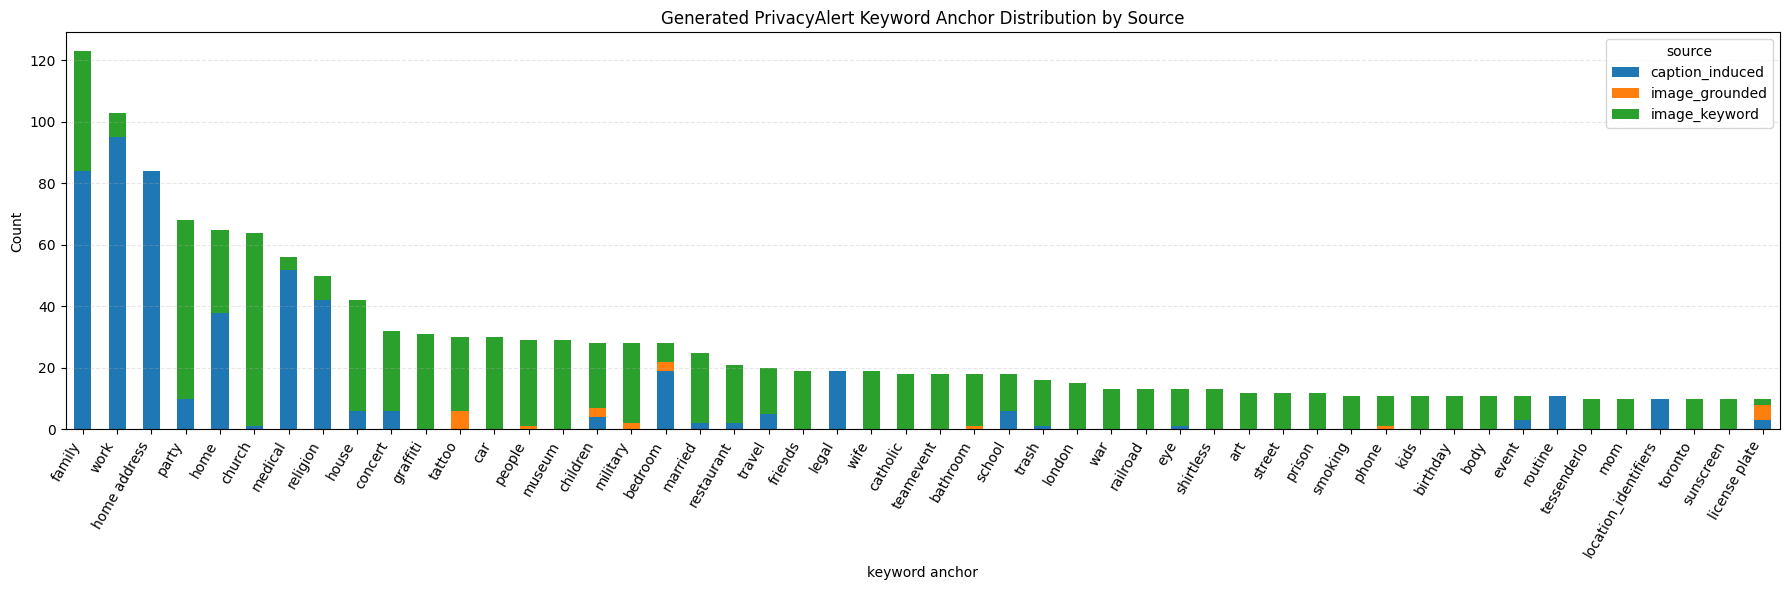

Saved: /content/drive/MyDrive/PrivacyAlert/experiments/caption_generation_keyword_induced_final_v2/graphs/generated_privacyalert_keyword_anchor_distribution.png
Saved: /content/drive/MyDrive/PrivacyAlert/experiments/caption_generation_keyword_induced_final_v2/reports/generated_keyword_anchor_counts_by_source.csv


In [ ]:

from collections import Counter
import pandas as pd
import json
from pathlib import Path


def load_generated_output_dfs(output_dir: Path):
    anchor_rows = []
    image_rows = []
    bad_files = []

    for jf in sorted(output_dir.glob('*.json')):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
            image_id = data.get('image_id', jf.stem)
            image_name = data.get('image_name', jf.name.replace('.json', '.jpg'))
            anchors = data.get('keyword_anchors', [])
            if not isinstance(anchors, list):
                anchors = []

            keyword_list = []
            source_counts = Counter()
            for item in anchors:
                if not isinstance(item, dict):
                    continue
                keyword = sanitize_keyword(item.get('keyword', ''))
                if not keyword:
                    continue
                source = str(item.get('source', '')).strip()
                if source not in VALID_ANCHOR_SOURCES:
                    source = 'unknown'
                keyword_list.append(keyword)
                source_counts[source] += 1
                anchor_rows.append({
                    'image_id': image_id,
                    'image_name': image_name,
                    'keyword': keyword,
                    'source': source,
                    'confidence': item.get('confidence', None),
                    'evidence': item.get('evidence', ''),
                    'json_path': str(jf),
                })

            image_rows.append({
                'image_id': image_id,
                'image_name': image_name,
                'num_keyword_anchors': len(set(keyword_list)),
                'keyword_anchors': sorted(set(keyword_list)),
                'image_keyword_count': source_counts.get(IMAGE_KEYWORD, 0),
                'image_grounded_count': source_counts.get(IMAGE_GROUNDED, 0),
                'caption_induced_count': source_counts.get(CAPTION_INDUCED, 0),
                'json_path': str(jf),
            })
        except Exception as e:
            bad_files.append({'json_path': str(jf), 'error': repr(e)})

    return pd.DataFrame(anchor_rows), pd.DataFrame(image_rows), pd.DataFrame(bad_files)


df_anchors, df_images, df_bad = load_generated_output_dfs(OUTPUT_DIR)

print('Generated JSON files:', len(list(OUTPUT_DIR.glob('*.json'))))
print('Bad JSON files:', len(df_bad))
print('Image rows:', len(df_images))
print('Keyword anchor rows:', len(df_anchors))

display(df_images.head())
display(df_anchors.head())
if len(df_bad):
    display(df_bad.head())

import matplotlib.pyplot as plt

def plot_generated_keyword_distribution(df_anchors: pd.DataFrame, top_n: int = 50):
    if df_anchors.empty:
        print('No keyword anchors found.')
        return pd.DataFrame()

    counts = (
        df_anchors
        .groupby(['keyword', 'source'])
        .size()
        .reset_index(name='count')
    )

    pivot = counts.pivot_table(
        index='keyword',
        columns='source',
        values='count',
        fill_value=0,
        aggfunc='sum',
    )

    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=False).head(top_n)

    display(pivot)

    ax = pivot.drop(columns=['total']).plot(kind='bar', stacked=True, figsize=(18, 6))
    ax.set_title('Generated PrivacyAlert Keyword Anchor Distribution by Source')
    ax.set_xlabel('keyword anchor')
    ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()

    out_path = GRAPH_DIR / 'generated_privacyalert_keyword_anchor_distribution.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)

    return pivot


generated_keyword_counts = plot_generated_keyword_distribution(df_anchors)
generated_keyword_counts.to_csv(REPORT_DIR / 'generated_keyword_anchor_counts_by_source.csv')
print('Saved:', REPORT_DIR / 'generated_keyword_anchor_counts_by_source.csv')

## 15. Gold PrivacyAlert keyword distribution vs generated anchors

,keyword,gold_image_count,gold_total_count,avg_source_count
1368,bathing,243,369,1.016461
5742,house,239,295,1.037657
7549,mini,231,241,1.034632
7143,maillot,229,374,1.008734
7560,miniskirt,225,226,1.004444
11133,suit,222,304,1.009009
11248,swimming,209,310,1.019139
5325,hair,206,294,1.063107
2228,cap,195,379,1.000000
8743,people,192,196,1.000000


,keyword,gold_image_count,gold_total_count,avg_source_count,generated_anchor_count
1370,bathing,243.0,369.0,1.016461,1
5750,house,239.0,295.0,1.037657,42
7561,mini,231.0,241.0,1.034632,1
7155,maillot,229.0,374.0,1.008734,0
7572,miniskirt,225.0,226.0,1.004444,1
...,...,...,...,...,...
1479,bell,93.0,178.0,1.000000,0
11903,tub,92.0,200.0,1.021739,1
8846,photography,92.0,97.0,1.000000,2
9730,restaurant,91.0,97.0,1.043956,21


Saved: /content/drive/MyDrive/PrivacyAlert/experiments/caption_generation_keyword_induced_final_v2/reports/gold_vs_generated_privacyalert_keyword_distribution.csv


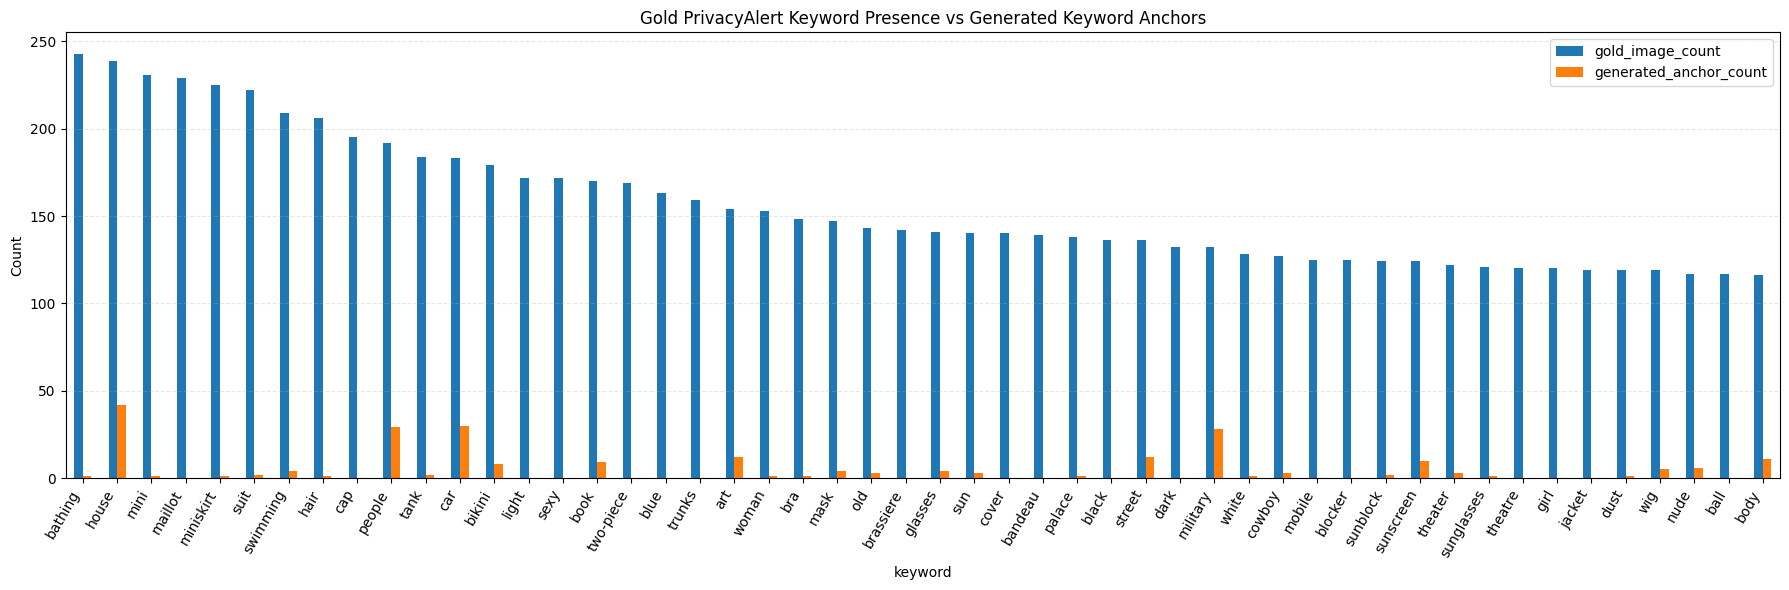

Saved: /content/drive/MyDrive/PrivacyAlert/experiments/caption_generation_keyword_induced_final_v2/graphs/gold_vs_generated_privacyalert_keywords.png


In [ ]:

def make_gold_keyword_distribution(contexts: dict):
    rows = []
    for image_id, ctx in contexts.items():
        for item in ctx.get('aggregated_keywords', []):
            rows.append({
                'image_id': image_id,
                'keyword': item['keyword'],
                'count': item['count'],
                'source_count': item['source_count'],
                'privacy': ctx.get('privacy'),
                'split': ctx.get('split'),
            })
    if not rows:
        return pd.DataFrame(columns=['keyword', 'gold_image_count', 'gold_total_count'])
    df = pd.DataFrame(rows)
    out = (
        df.groupby('keyword')
        .agg(
            gold_image_count=('image_id', 'nunique'),
            gold_total_count=('count', 'sum'),
            avg_source_count=('source_count', 'mean'),
        )
        .reset_index()
        .sort_values('gold_image_count', ascending=False)
    )
    return out


gold_keywords = make_gold_keyword_distribution(privacyalert_contexts)
display(gold_keywords.head(50))

generated_keywords_simple = (
    df_anchors['keyword']
    .value_counts()
    .rename_axis('keyword')
    .reset_index(name='generated_anchor_count')
) if not df_anchors.empty else pd.DataFrame(columns=['keyword', 'generated_anchor_count'])

merged_dist = gold_keywords.merge(generated_keywords_simple, on='keyword', how='outer').fillna(0)
merged_dist['generated_anchor_count'] = merged_dist['generated_anchor_count'].astype(int)
merged_dist = merged_dist.sort_values('gold_image_count', ascending=False)

display(merged_dist.head(100))
merged_dist.to_csv(REPORT_DIR / 'gold_vs_generated_privacyalert_keyword_distribution.csv', index=False)
print('Saved:', REPORT_DIR / 'gold_vs_generated_privacyalert_keyword_distribution.csv')


def plot_gold_vs_generated_keywords(merged_dist: pd.DataFrame, top_n: int = 50):
    if merged_dist.empty:
        print('Nothing to plot.')
        return

    plot_df = merged_dist.head(top_n).set_index('keyword')[['gold_image_count', 'generated_anchor_count']]
    ax = plot_df.plot(kind='bar', figsize=(18, 6))
    ax.set_title('Gold PrivacyAlert Keyword Presence vs Generated Keyword Anchors')
    ax.set_xlabel('keyword')
    ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()

    out_path = GRAPH_DIR / 'gold_vs_generated_privacyalert_keywords.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)

plot_gold_vs_generated_keywords(merged_dist)

## 16. Inspect individual outputs

In [ ]:

def show_output(image_id_or_name: str):
    key = image_id_from_path(Path(image_id_or_name)) if not str(image_id_or_name).isdigit() else str(image_id_or_name)
    jf = OUTPUT_DIR / f'{key}.json'
    if not jf.exists():
        print('Missing:', jf)
        return

    data = json.loads(jf.read_text(encoding='utf-8'))

    print('image:', data.get('image_name'))
    print('image_id:', data.get('image_id'))
    print('explicit:', data.get('captions', {}).get('explicit', ''))
    print('no_leak:', data.get('captions', {}).get('no_leak', ''))
    print('\nkeyword anchors:')
    for item in data.get('keyword_anchors', []):
        print('-', item)

    ctx = data.get('privacyalert_context') or {}
    print('\nPrivacyAlert label:', ctx.get('privacy'))
    print('Top keywords:', ctx.get('aggregated_keywords', [])[:20])

# Example:
if len(df_images):
    show_output(df_images.iloc[0]['image_id'])

image: 10560439084.jpg
image_id: 10560439084
explicit: Finally getting the living room setup together in my new apartment; the red sofa is definitely the statement piece I needed.
no_leak: Love the bold design of this space, it makes for a perfect, cozy corner.

keyword anchors:
- {'keyword': 'apartment', 'source': 'image_keyword', 'evidence': 'new apartment', 'confidence': 0.7}
- {'keyword': 'sofa', 'source': 'image_grounded', 'evidence': 'red sofa', 'confidence': 0.7}
- {'keyword': 'living room', 'source': 'caption_induced', 'evidence': 'living room setup', 'confidence': 0.7}

PrivacyAlert label: Public
Top keywords: [{'keyword': 'home', 'count': 3, 'sources': ['deep_tags', 'user_tags'], 'source_count': 2}, {'keyword': 'couch', 'count': 2, 'sources': ['deep_tags', 'user_tags'], 'source_count': 2}, {'keyword': 'house', 'count': 2, 'sources': ['deep_tags', 'user_tags'], 'source_count': 2}, {'keyword': 'lamp', 'count': 2, 'sources': ['deep_tags', 'user_tags'], 'source_count': 2}, {'keyw

## 17. Optional: visualize image with PrivacyAlert context

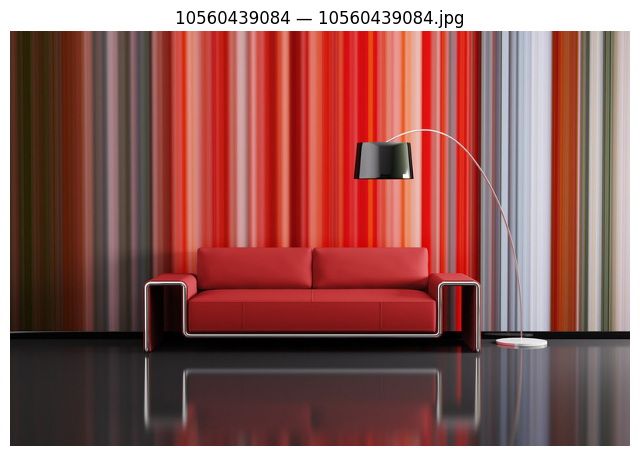

image_id: 10560439084
split: test
privacy_label: Public
binary_privacy: 0
cleaned_image_keywords: ['home', 'couch', 'house', 'lamp', 'movie', 'speaker', 'system', 'theater', 'theatre', 'curtain', 'design', 'interior', 'loudspeaker', 'television', '3d', 'altersgenosse', 'apartment', 'architecture', 'architektur', 'background', 'bed', 'black', 'boden', 'cinema', 'contemporary', 'day', 'flat', 'floor', 'furniture', 'haus', 'hintergrund', 'indoors', 'innen', 'innenaufnahme', 'innenraum', 'inside', 'lampe', 'living', 'minimalism', 'modern', 'möbel', 'möbliert', 'palace', 'picture', 'raum', 'red', 'render', 'room', 'rot', 'schwarz', 'seat', 'shade', 'sofa', 'studio', 'table', 'throne', 'ukraine', 'unit', 'velvet', 'wall', 'wallpaper', 'wand', 'window', 'wohnung', 'wohnzimmer', 'zimmer']
image_grounded_privacy_keywords: ['home', 'couch', 'house', 'lamp', 'movie', 'speaker', 'system', 'theater', 'theatre', 'curtain', 'design', 'interior', 'loudspeaker', 'television', '3d', 'altersgenosse', 'ap

In [ ]:

from PIL import Image
import matplotlib.pyplot as plt


def show_image_and_context(image_path_or_id):
    if isinstance(image_path_or_id, Path):
        img_path = image_path_or_id
        image_id = image_id_from_path(img_path)
    else:
        s = str(image_path_or_id)
        image_id = s if s.isdigit() else image_id_from_path(Path(s))
        img_path = image_id_to_path.get(image_id)

    if img_path is None or not img_path.exists():
        print('Missing image for:', image_id)
        return

    img = Image.open(img_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{image_id} — {img_path.name}')
    plt.show()

    print(context_to_prompt_text(privacyalert_contexts.get(image_id))[:6000])

# Example:
if images_to_process:
    show_image_and_context(images_to_process[0])

## Notes

Recommended workflow:
1. Keep `MAX_IMAGES = 5`, run once, and inspect outputs.
2. If your image folder is empty, run the optional downloader cell with `MAX_DOWNLOADS = 20`, then rerun Cell 7.
3. If outputs look good, set `MAX_IMAGES = None`.
4. Choose the split with `SPLIT_TO_PROCESS = 'test'`, `'train'`, `'val'`, or `'all'`.
5. Set `PROCESS_ONLY_PRIVATE = True` if you only want originally private PrivacyAlert images.
6. Keep `SKIP_IF_JSON_EXISTS = True` so the run is resumable.